
# 14. Classification, Probability Models, and Calibration

Many decision problems in data science are not about estimating a continuous outcome. They are about estimating the probability of an event: a customer churns, a payment is fraudulent, a premium-support case breaches its SLA, a patient deteriorates, or a loan defaults. In all of these settings, the model estimates risk levels as well as case rankings. It is producing numbers that people may interpret as probabilities and then use to allocate resources, trigger interventions, or justify action.

That distinction matters. A model can rank cases well and still produce probabilities that are too extreme or too timid. It can post a strong overall accuracy while missing most rare events. It can look excellent on an ROC curve while performing poorly in the region decision makers actually care about. Good classification work therefore has three layers:

1. discrimination: does the model separate positives from negatives;
2. calibration: do predicted probabilities line up with observed frequencies;
3. decision alignment: does the operating threshold reflect the cost of false positives, false negatives, and workflow capacity.

We develop those ideas in one coherent example. We study a premium-support triage problem in which the event of interest is an SLA breach. Along the way we compare a linear probability model, logistic regression, a flexible random forest score model, and a calibrated version of that random forest. The goal is to learn how to turn model output into defensible operational judgment, with metrics serving that larger purpose.



## Learning Objectives

After working through this lecture, you should be able to:

- explain why binary classification in decision settings is fundamentally a probability estimation problem with label prediction as one use case;
- diagnose why high accuracy can be misleading when the event rate is low;
- distinguish the linear probability model from logistic regression, especially with respect to bounded probabilities and interpretation;
- compare ranking-oriented metrics such as ROC AUC and average precision with probability-oriented metrics such as Brier score and log loss;
- interpret calibration curves and reliability tables as checks on whether a predicted risk score can be trusted numerically;
- choose a classification threshold using explicit false-positive and false-negative costs with the arbitrary 0.50 default treated as only one candidate;
- articulate when a model is useful for ranking, when it is useful for probability estimation, and when it is usable for action.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import inspect
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from scipy.special import expit
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
np.random.seed(7)


def make_sla_classification_data(n=5000, seed=7):
    """
    Construct the sla classification data object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame for SLA-breach classification, including nonlinear risk drivers, labels, and decision-relevant covariates.
    
    Idea:
        Build a binary risk-prediction setting where ranking, calibration, and threshold choice can be separated cleanly.
    """
    rng = np.random.default_rng(seed)

    severity_levels = np.array(['Low', 'Medium', 'High', 'Critical'])
    severity = rng.choice(severity_levels, size=n, p=[0.35, 0.33, 0.22, 0.10])
    severity_score = pd.Series(severity).map({'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}).to_numpy()

    queue_load = np.clip(rng.normal(loc=1.0 + 0.08 * severity_score, scale=0.22, size=n), 0.45, 1.90)
    analyst_experience_years = np.clip(rng.gamma(shape=3.2, scale=1.6, size=n), 0.2, 15.0)
    prior_tickets = np.clip(rng.poisson(lam=1.2 + 0.55 * severity_score, size=n), 0, 12)
    self_service_share = np.clip(rng.beta(2.5, 2.2, size=n) - 0.04 * severity_score, 0.02, 0.98)
    priority_account = rng.binomial(1, np.clip(0.12 + 0.07 * severity_score, 0.05, 0.45), size=n)
    weekend_intake = rng.binomial(1, 0.23, size=n)
    anomaly_score = np.clip(rng.beta(1.8 + 0.45 * severity_score, 4.0, size=n) * 5.0, 0.0, 5.0)

    latent_logit = (
        -4.20
        + 1.75 * (queue_load - 1.0)
        + 0.34 * severity_score
        - 0.11 * analyst_experience_years
        + 0.10 * prior_tickets
        - 1.05 * self_service_share
        + 0.60 * priority_account
        + 0.55 * weekend_intake
        + 0.72 * anomaly_score
        + 0.85 * (queue_load - 1.0) * weekend_intake
        + 0.30 * anomaly_score * priority_account
    )

    breach_probability = expit(latent_logit)
    sla_breach = rng.binomial(1, breach_probability, size=n)

    df = pd.DataFrame(
        {
            'queue_load': queue_load,
            'analyst_experience_years': analyst_experience_years,
            'prior_tickets': prior_tickets,
            'self_service_share': self_service_share,
            'priority_account': priority_account,
            'weekend_intake': weekend_intake,
            'anomaly_score': anomaly_score,
            'severity': severity,
            'true_breach_probability': breach_probability,
            'sla_breach': sla_breach,
        }
    )

    df['priority_account'] = df['priority_account'].map({0: 'No', 1: 'Yes'})
    df['weekend_intake'] = df['weekend_intake'].map({0: 'Weekday', 1: 'Weekend'})
    return df


def probability_metrics(y_true, prob, threshold=0.50):
    """
    Compute the probability metrics quantity used in the statistical or decision-science workflow.
    
    Parameters:
        y_true: Observed outcome values.
        prob: Probability or rate parameter used in the calculation.
        threshold: Decision or statistical threshold used to define the target, interval, or rule.
    
    Returns:
        A dictionary of classification metrics, including threshold metrics, ROC AUC, average precision, Brier score, and log loss.
    
    Idea:
        Evaluate probabilistic classifiers with scoring rules and discrimination metrics so both ranking and probability quality are visible.
    """
    prob = np.clip(np.asarray(prob), 1e-6, 1 - 1e-6)
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        'accuracy@0.50': accuracy_score(y_true, pred),
        'precision@0.50': precision_score(y_true, pred, zero_division=0),
        'recall@0.50': recall_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, prob),
        'average_precision': average_precision_score(y_true, prob),
        'brier_score': brier_score_loss(y_true, prob),
        'log_loss': log_loss(y_true, prob),
        'alert_rate@0.50': pred.mean(),
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
        'true_negatives': tn,
    }


def reliability_table(y_true, prob, bins=10):
    """
    Compute the reliability table quantity used in the statistical or decision-science workflow.
    
    Parameters:
        y_true: Observed outcome values.
        prob: Probability or rate parameter used in the calculation.
        bins: Input used by `bins` in this helper.
    
    Returns:
        A pandas DataFrame comparing predicted-probability bins with observed event rates for calibration assessment.
    
    Idea:
        Bin predicted risks against observed outcomes to diagnose whether model probabilities are trustworthy for threshold decisions.
    """
    table = pd.DataFrame({'observed': y_true, 'predicted': prob})
    table['bin'] = pd.qcut(table['predicted'], q=bins, duplicates='drop')
    summary = (
        table.groupby('bin', observed=False)
        .agg(
            count=('observed', 'size'),
            mean_predicted=('predicted', 'mean'),
            observed_rate=('observed', 'mean'),
        )
        .reset_index()
    )
    summary['calibration_gap'] = summary['observed_rate'] - summary['mean_predicted']
    summary['bin'] = summary['bin'].astype(str)
    return summary


def expected_calibration_error(y_true, prob, bins=10):
    """
    Compute the expected calibration error quantity used in the statistical or decision-science workflow.
    
    Parameters:
        y_true: Observed outcome values.
        prob: Probability or rate parameter used in the calculation.
        bins: Input used by `bins` in this helper.
    
    Returns:
        A NumPy-compatible numeric result produced by `expected_calibration_error` for the surrounding simulation or inference workflow.
    
    Idea:
        Summarize calibration gaps across risk bins so probability quality can be evaluated as a decision property, as a decision property and as a plot.
    """
    table = reliability_table(y_true, prob, bins=bins)
    weights = table['count'] / table['count'].sum()
    return np.average(np.abs(table['calibration_gap']), weights=weights)


def threshold_table(y_true, prob, thresholds, fp_cost=120, fn_cost=1500):
    """
    Compute the threshold table quantity used in the statistical or decision-science workflow.
    
    Parameters:
        y_true: Observed outcome values.
        prob: Probability or rate parameter used in the calculation.
        thresholds: Decision or statistical threshold used to define the target, interval, or rule.
        fp_cost: Decision-scale quantity used in the cost, value, or operational calculation.
        fn_cost: Decision-scale quantity used in the cost, value, or operational calculation.
    
    Returns:
        A pandas DataFrame of threshold-specific classification outcomes, costs, and decision metrics.
    
    Idea:
        Evaluate classification thresholds as policy choices, showing the tradeoff among alerts, misses, and workload.
    """
    rows = []
    n = len(y_true)
    for threshold in thresholds:
        pred = (prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        rows.append(
            {
                'threshold': threshold,
                'alert_rate': pred.mean(),
                'precision': precision,
                'recall': recall,
                'false_positives': fp,
                'false_negatives': fn,
                'expected_cost_per_case': (fp_cost * fp + fn_cost * fn) / n,
                'expected_cost_per_1000_cases': 1000 * (fp_cost * fp + fn_cost * fn) / n,
            }
        )
    return pd.DataFrame(rows)


## 1. The Decision Problem: Predicting Event Risk and Labels

Suppose we run a premium-support operation for enterprise customers. Every incoming case is assigned to a queue, handled by an analyst, and judged against a service-level agreement (SLA). Leadership wants a *risk estimate early enough to intervene*, along with the eventual breach label.

This is why binary classification belongs inside decision science. A probability estimate lets us:

- prioritize the highest-risk cases for immediate escalation;
- estimate how many alerts a team can handle under a chosen threshold;
- trade off the cost of unnecessary escalations against the cost of missed failures;
- communicate uncertainty because cases are rarely simply safe or unsafe.

We will work with a simulated but realistic dataset in which each row represents one support case and the target variable is whether the case breached the SLA.


In [2]:
# Build a summary table that supports the interpretation in the surrounding notes.
classification_df = make_sla_classification_data(n=5000, seed=7)
train_df, test_df = train_test_split(
    classification_df,
    test_size=0.35,
    stratify=classification_df['sla_breach'],
    random_state=7,
)

smart_display(classification_df.head())

summary_table = pd.DataFrame(
    {
        'split': ['Training', 'Test', 'Overall'],
        'cases': [len(train_df), len(test_df), len(classification_df)],
        'breach_rate': [train_df['sla_breach'].mean(), test_df['sla_breach'].mean(), classification_df['sla_breach'].mean()],
        'avg_queue_load': [train_df['queue_load'].mean(), test_df['queue_load'].mean(), classification_df['queue_load'].mean()],
        'avg_anomaly_score': [train_df['anomaly_score'].mean(), test_df['anomaly_score'].mean(), classification_df['anomaly_score'].mean()],
    }
)
smart_display(summary_table)

display(
    Markdown(
        f"The overall breach prevalence is **{classification_df['sla_breach'].mean():.1%}**, "
        f"with **{len(train_df):,}** cases used for training and **{len(test_df):,}** reserved for evaluation. "
        "This is rare enough that accuracy will need careful interpretation, but common enough that probability calibration remains observable in the test set."
    )
)


,queue_load,analyst_experience_years,prior_tickets,self_service_share,priority_account,weekend_intake,anomaly_score,severity,true_breach_probability,sla_breach
0,1.174,1.075,2,0.713,No,Weekday,1.405,Medium,0.039,0
1,1.344,15.000,0,0.706,No,Weekday,2.213,High,0.024,0
2,1.328,15.000,2,0.234,Yes,Weekday,1.636,High,0.085,0
3,0.934,8.227,1,0.712,No,Weekend,0.220,Low,0.005,0
4,1.095,4.038,1,0.502,Yes,Weekday,1.418,Low,0.054,0


,split,cases,breach_rate,avg_queue_load,avg_anomaly_score
0,Training,3250,0.088,1.082,1.820
1,Test,1750,0.089,1.086,1.788
2,Overall,5000,0.088,1.084,1.808


The overall breach prevalence is **8.8%**, with **3,250** cases used for training and **1,750** reserved for evaluation. This is rare enough that accuracy will need careful interpretation, but common enough that probability calibration remains observable in the test set.

### Dataset and Experiment Design

The synthetic dataset represents a support-risk classification problem. Each row is a case that may or may not breach an SLA. The features include queue load, analyst experience, prior tickets, self-service completion, account priority, weekend intake, anomaly score, and severity. The event is intentionally uncommon, so accuracy by itself can be misleading.

The experiment compares four probability workflows: a linear probability model, logistic regression, an uncalibrated random forest, and a calibrated random forest. That mix is deliberate. It lets us separate ranking ability from probability calibration and threshold choice. A model can put the riskiest cases near the top of the queue while still producing probabilities that are too high or too low.

The dataset is nonlinear but controlled. That gives each model something meaningful to learn while preserving the central teaching question: when a predicted score becomes part of a decision system, do we trust it as a rank, as a probability, or as a threshold rule?


### Variable Guide

| Variable | Role | Why It Matters for Triage |
|---|---|---|
| `queue_load` | Current congestion signal | Higher queue pressure raises the chance that a case waits too long. |
| `analyst_experience_years` | Workforce capability proxy | More experienced analysts often resolve cases faster and escalate more selectively. |
| `prior_tickets` | Customer friction history | Repeated prior tickets can signal unresolved complexity or recurring failures. |
| `self_service_share` | Upstream problem resolution | Cases with stronger self-service completion often arrive cleaner and easier to close. |
| `priority_account` | Contractual urgency flag | Premium customers may be triaged differently and may impose tighter service expectations. |
| `weekend_intake` | Staffing-context indicator | Weekend cases may face thinner coverage or slower escalation pathways. |
| `anomaly_score` | Existing heuristic risk score | This mimics a rough operational alert score available before final resolution. |
| `severity` | Business-critical case label | More severe cases naturally face higher operational risk. |
| `sla_breach` | Binary outcome | The event we want to predict and prevent. |



The data-generating process is intentionally nonlinear. Queue pressure matters more on weekends, anomaly scores interact with account priority, and the event probability is created through a logistic link with bounded probabilities. That makes the example useful: it gives the linear probability model a fair chance to be informative while still revealing why probability modeling choices matter.



## 2. The Base-Rate Problem: Why Accuracy Can Be Misleading

When the positive event is relatively uncommon, a weak classifier can still look strong if we judge it by accuracy alone. If only 15% of cases breach, a naive rule that predicts "no breach" for every case will be about 85% accurate while catching none of the actual failures.

That is the first mental shift in classification work: the right benchmark is not "better than 50-50 guessing." The right benchmark is often a base-rate-aware rule that exploits class imbalance without learning anything useful.


In [3]:
# Build a summary table that supports the interpretation in the surrounding notes.
y_test = test_df['sla_breach'].to_numpy()
prevalence = y_test.mean()
always_negative = np.zeros_like(y_test)
prevalence_prob = np.full_like(y_test, fill_value=prevalence, dtype=float)

after_no_alert_accuracy = accuracy_score(y_test, always_negative)
after_no_alert_recall = recall_score(y_test, always_negative, zero_division=0)
prevalence_brier = brier_score_loss(y_test, prevalence_prob)

baseline_table = pd.DataFrame(
    {
        'baseline_rule': ['Always predict no breach', 'Predict the base rate for every case'],
        'accuracy_or_brier': [after_no_alert_accuracy, prevalence_brier],
        'quantity_reported': ['Accuracy', 'Brier score'],
        'event_recall': [after_no_alert_recall, np.nan],
    }
)
smart_display(baseline_table)

display(
    Markdown(
        f"On the held-out test set, an always-negative classifier reaches **{after_no_alert_accuracy:.1%} accuracy** but **{after_no_alert_recall:.1%} recall**. "
        f"That is the classic accuracy trap. A separate probability-only baseline that predicts the event rate for everyone yields a **Brier score of {prevalence_brier:.3f}**. "
        "Any serious model should improve on both baselines, but it must do so in ways that line up with the operational decision."
    )
)


,baseline_rule,accuracy_or_brier,quantity_reported,event_recall
0,Always predict no breach,0.911429,Accuracy,0.000000
1,Predict the base rate for every case,0.080727,Brier score,nan


On the held-out test set, an always-negative classifier reaches **91.1% accuracy** but **0.0% recall**. That is the classic accuracy trap. A separate probability-only baseline that predicts the event rate for everyone yields a **Brier score of 0.081**. Any serious model should improve on both baselines, but it must do so in ways that line up with the operational decision.


The baseline already tells us something practical. If a future model claims 88% accuracy, that number is not automatically impressive. We need to ask whether it is actually identifying more of the rare, costly failures, whether its probabilities are trustworthy, and whether the workload implied by its alert threshold is manageable.



## 3. Fit Four Competing Models

We now fit four models on the training split:

1. a **linear probability model (LPM)** using ordinary least squares;
2. a **logistic regression** with the same predictors;
3. an **uncalibrated random forest** as a flexible score model;
4. an **isotonic-calibrated random forest** that keeps the forest's ranking information while trying to repair its probability scale.

This combination is pedagogically useful because it separates three issues:

- linear versus nonlinear modeling;
- interpretable coefficients versus flexible pattern capture;
- ranking quality versus probability calibration.


In [4]:
# Fit the statistical or machine-learning model used for this comparison.
formula = (
    'sla_breach ~ queue_load + analyst_experience_years + prior_tickets + '
    'self_service_share + anomaly_score + C(severity) + C(priority_account) + C(weekend_intake)'
)

lpm_model = smf.ols(formula, data=train_df).fit()
logit_model = smf.glm(formula, data=train_df, family=sm.families.Binomial()).fit()

feature_columns = [
    'queue_load',
    'analyst_experience_years',
    'prior_tickets',
    'self_service_share',
    'priority_account',
    'weekend_intake',
    'anomaly_score',
    'severity',
]

categorical_features = ['priority_account', 'weekend_intake', 'severity']
numeric_features = [
    'queue_load',
    'analyst_experience_years',
    'prior_tickets',
    'self_service_share',
    'anomaly_score',
]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ('prep', preprocess),
        ('model', RandomForestClassifier(n_estimators=250, min_samples_leaf=18, random_state=7)),
    ]
)
rf_pipeline.fit(train_df[feature_columns], train_df['sla_breach'])

calibrator_kwargs = {'method': 'isotonic', 'cv': 5}
if 'estimator' in inspect.signature(CalibratedClassifierCV).parameters:
    calibrator_kwargs['estimator'] = Pipeline(
        steps=[
            ('prep', preprocess),
            ('model', RandomForestClassifier(n_estimators=250, min_samples_leaf=18, random_state=7)),
        ]
    )
else:
    calibrator_kwargs['base_estimator'] = Pipeline(
        steps=[
            ('prep', preprocess),
            ('model', RandomForestClassifier(n_estimators=250, min_samples_leaf=18, random_state=7)),
        ]
    )

rf_calibrated = CalibratedClassifierCV(**calibrator_kwargs)
rf_calibrated.fit(train_df[feature_columns], train_df['sla_breach'])

lpm_prob = lpm_model.predict(test_df)
logit_prob = logit_model.predict(test_df)
rf_prob = rf_pipeline.predict_proba(test_df[feature_columns])[:, 1]
rf_cal_prob = rf_calibrated.predict_proba(test_df[feature_columns])[:, 1]



## 4. The Linear Probability Model Is Useful, but It Is Not a Probability Model in the Strict Sense

The linear probability model treats the expected value of a binary outcome as a linear function of predictors. Because the binary variable takes values 0 and 1, the fitted value can be interpreted as a predicted probability. That interpretation is often helpful as a first approximation, especially because coefficients are simple to read.

But the linear form also creates an immediate structural problem:

$$
E[Y_i \,|\, X_i] = \beta_0 + \beta_1 X_{i1} + \cdots + \beta_p X_{ip}
$$

is unconstrained, while a genuine probability must lie in the interval $[0,1]$. Once the fitted line is extrapolated into low-risk or high-risk corners of the feature space, the model can produce values below 0 or above 1.


,model,min_prediction,max_prediction,share_below_zero,share_above_one
0,Linear probability model,-0.186,0.452,0.202,0.000
1,Logistic regression,0.001,0.858,0.000,0.000


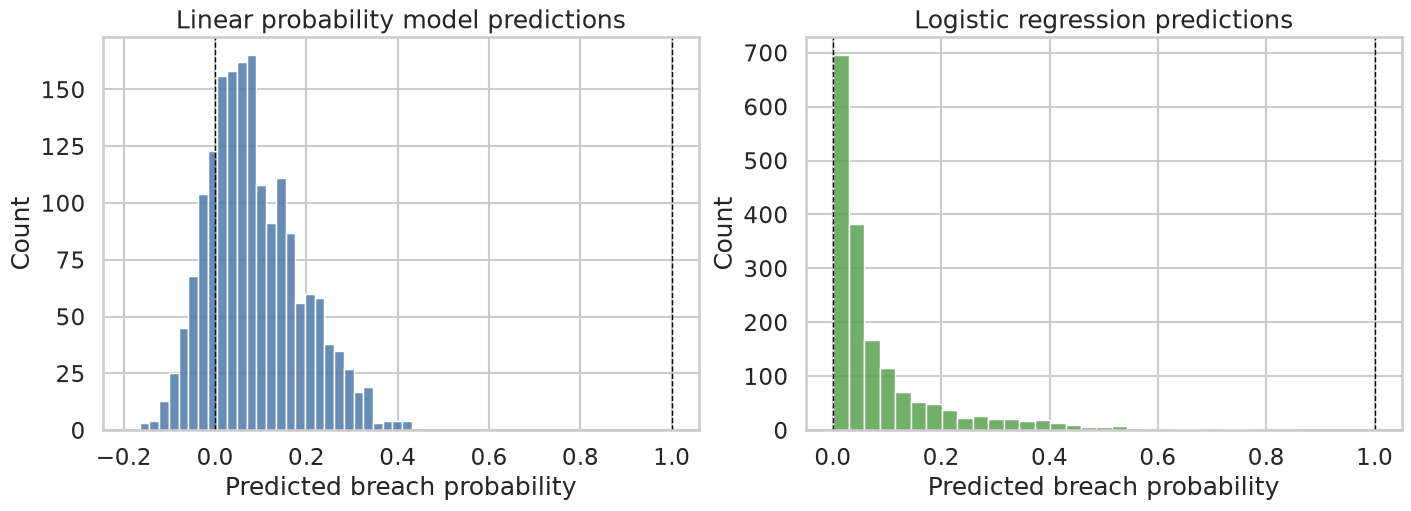

On the test set, the linear probability model produces **354 predictions below 0** and **0 predictions above 1**. The histogram makes the geometry visible: OLS is trying to fit an event rate with a straight line, while logistic regression automatically respects the probability bounds.

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
lpm_summary = pd.DataFrame(
    {
        'model': ['Linear probability model', 'Logistic regression'],
        'min_prediction': [lpm_prob.min(), logit_prob.min()],
        'max_prediction': [lpm_prob.max(), logit_prob.max()],
        'share_below_zero': [(lpm_prob < 0).mean(), (logit_prob < 0).mean()],
        'share_above_one': [(lpm_prob > 1).mean(), (logit_prob > 1).mean()],
    }
)
smart_display(lpm_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.histplot(lpm_prob, bins=30, color='#4C78A8', alpha=0.85, ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].axvline(1, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Linear probability model predictions')
axes[0].set_xlabel('Predicted breach probability')

sns.histplot(logit_prob, bins=30, color='#59A14F', alpha=0.85, ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(1, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Logistic regression predictions')
axes[1].set_xlabel('Predicted breach probability')

plt.show()

below_zero = int((lpm_prob < 0).sum())
above_one = int((lpm_prob > 1).sum())
display(
    Markdown(
        f"On the test set, the linear probability model produces **{below_zero} predictions below 0** and **{above_one} predictions above 1**. "
        "The histogram makes the geometry visible: OLS is trying to fit an event rate with a straight line, while logistic regression automatically respects the probability bounds."
    )
)



The linear probability model can still be a valuable baseline, and its coefficients are often easy to communicate. When the analysis will be used as a probability engine for triage, staffing, or expected-cost calculations, bounded predictions are a real practical advantage.



## 5. Logistic Regression: Interpretable Risk Modeling with a Proper Probability Link

Logistic regression replaces the straight-line mean function with the log-odds link:

$$
\log\left( \frac{p_i}{1-p_i} \right) = \beta_0 + \beta_1 X_{i1} + \cdots + \beta_p X_{ip}.
$$

This transformation matters because the inverse-logit map turns any real-valued linear predictor into a valid probability:

$$
p_i = \frac{1}{1 + e^{-\eta_i}}.
$$

The coefficients now live on the log-odds scale. Exponentiating them gives odds ratios, which are often easier to interpret. Even then, the best practical habit is to translate model output into scenario-based probabilities together with any odds-ratio interpretation.


In [6]:
# Build a summary table that supports the interpretation in the surrounding notes.
logit_terms = pd.DataFrame(
    {
        'term': logit_model.params.index,
        'coefficient': logit_model.params.values,
        'odds_ratio': np.exp(logit_model.params.values),
    }
)
logit_terms['abs_coefficient'] = logit_terms['coefficient'].abs()
logit_terms = logit_terms.sort_values('abs_coefficient', ascending=False).drop(columns='abs_coefficient')
smart_display(logit_terms)

scenarios = pd.DataFrame(
    [
        {
            'scenario': 'Calm weekday, low severity',
            'queue_load': 0.75,
            'analyst_experience_years': 7.5,
            'prior_tickets': 0,
            'self_service_share': 0.80,
            'priority_account': 'No',
            'weekend_intake': 'Weekday',
            'anomaly_score': 0.8,
            'severity': 'Low',
        },
        {
            'scenario': 'Busy weekday, medium severity',
            'queue_load': 1.10,
            'analyst_experience_years': 4.0,
            'prior_tickets': 2,
            'self_service_share': 0.45,
            'priority_account': 'No',
            'weekend_intake': 'Weekday',
            'anomaly_score': 2.2,
            'severity': 'Medium',
        },
        {
            'scenario': 'Weekend priority escalation',
            'queue_load': 1.35,
            'analyst_experience_years': 2.0,
            'prior_tickets': 4,
            'self_service_share': 0.25,
            'priority_account': 'Yes',
            'weekend_intake': 'Weekend',
            'anomaly_score': 3.7,
            'severity': 'High',
        },
        {
            'scenario': 'Critical overload event',
            'queue_load': 1.65,
            'analyst_experience_years': 1.0,
            'prior_tickets': 6,
            'self_service_share': 0.10,
            'priority_account': 'Yes',
            'weekend_intake': 'Weekend',
            'anomaly_score': 4.6,
            'severity': 'Critical',
        },
    ]
)

scenario_results = scenarios.copy()
scenario_results['lpm_probability'] = lpm_model.predict(scenarios)
scenario_results['logit_probability'] = logit_model.predict(scenarios)
scenario_results['rf_probability'] = rf_pipeline.predict_proba(scenarios[feature_columns])[:, 1]
scenario_results['rf_calibrated_probability'] = rf_calibrated.predict_proba(scenarios[feature_columns])[:, 1]
smart_display(scenario_results)

highest_risk = scenario_results.sort_values('logit_probability', ascending=False).iloc[0]
lowest_risk = scenario_results.sort_values('logit_probability', ascending=True).iloc[0]

display(
    Markdown(
        f"The scenario table makes the interpretation concrete. Logistic regression assigns only **{lowest_risk['logit_probability']:.1%}** risk to the calm low-severity case, "
        f"but roughly **{highest_risk['logit_probability']:.1%}** to the critical overload case. "
        "That kind of translation is far more actionable than quoting a coefficient alone, and it also reveals whether different models agree on the same operational stories."
    )
)


,term,coefficient,odds_ratio
0,Intercept,-5.319,0.005
6,queue_load,2.108,8.234
4,C(priority_account)[T.Yes],1.202,3.326
9,self_service_share,-1.198,0.302
2,C(severity)[T.Low],-0.877,0.416
3,C(severity)[T.Medium],-0.726,0.484
10,anomaly_score,0.712,2.039
5,C(weekend_intake)[T.Weekend],0.543,1.720
1,C(severity)[T.High],-0.282,0.754
8,prior_tickets,0.156,1.168


,scenario,queue_load,analyst_experience_years,prior_tickets,self_service_share,priority_account,weekend_intake,anomaly_score,severity,lpm_probability,logit_probability,rf_probability,rf_calibrated_probability
0,"Calm weekday, low severity",0.750000,7.500000,0,0.800000,No,Weekday,0.800000,Low,-0.117554,0.002316,0.017514,0.014737
1,"Busy weekday, medium severity",1.100000,4.000000,2,0.450000,No,Weekday,2.200000,Medium,0.069004,0.049626,0.047363,0.036931
2,Weekend priority escalation,1.350000,2.000000,4,0.250000,Yes,Weekend,3.700000,High,0.432419,0.840931,0.477412,0.850000
3,Critical overload event,1.650000,1.000000,6,0.100000,Yes,Weekend,4.600000,Critical,0.627681,0.979238,0.507201,0.850000


The scenario table makes the interpretation concrete. Logistic regression assigns only **0.2%** risk to the calm low-severity case, but roughly **97.9%** to the critical overload case. That kind of translation is far more actionable than quoting a coefficient alone, and it also reveals whether different models agree on the same operational stories.


The scenario comparison is also a reminder that interpretability is about more than coefficients. It is about whether we can explain how the model reacts as conditions become more congested, more severe, or more operationally abnormal.



## 6. Ranking Quality Versus Probability Quality

A classification model can be asked to do at least two different jobs.

- **Ranking job:** place truly risky cases above safer cases.
- **Probability job:** produce numbers that numerically match event frequencies.

Those jobs overlap, but they are not identical. ROC AUC and average precision are mainly about ordering. Brier score and log loss care about the probability scale itself. Accuracy, precision, and recall depend both on the model and on the chosen threshold.

This is exactly why we compare several metrics side by side.


In [7]:
# Simulate data or resample observations to study variability and uncertainty.
model_predictions = {
    'Linear probability model': np.clip(lpm_prob, 1e-6, 1 - 1e-6),
    'Logistic regression': np.clip(logit_prob, 1e-6, 1 - 1e-6),
    'Random forest': np.clip(rf_prob, 1e-6, 1 - 1e-6),
    'Calibrated random forest': np.clip(rf_cal_prob, 1e-6, 1 - 1e-6),
}

metrics_rows = []
for model_name, prob in model_predictions.items():
    metrics = probability_metrics(y_test, prob, threshold=0.50)
    metrics['ece_10_bins'] = expected_calibration_error(y_test, prob, bins=10)
    metrics['model'] = model_name
    metrics_rows.append(metrics)

metrics_table = pd.DataFrame(metrics_rows).set_index('model')
metrics_table = metrics_table[
    [
        'accuracy@0.50',
        'precision@0.50',
        'recall@0.50',
        'alert_rate@0.50',
        'roc_auc',
        'average_precision',
        'brier_score',
        'log_loss',
        'ece_10_bins',
    ]
].sort_values(['brier_score', 'log_loss'])
smart_display(metrics_table.reset_index())

best_auc_model = metrics_table['roc_auc'].idxmax()
best_brier_model = metrics_table['brier_score'].idxmin()
zero_alert_models = metrics_table.index[metrics_table['alert_rate@0.50'] <= 1e-12].tolist()

if best_auc_model == best_brier_model:
    headline = (
        f"In this simulation, **{best_auc_model}** is strongest on both **ROC AUC** and **Brier score**, "
        "so the same model is winning both the ranking and probability-quality comparisons."
    )
else:
    headline = (
        f"The best **ranking** performance by ROC AUC comes from **{best_auc_model}**, while the best **probability** performance by Brier score comes from **{best_brier_model}**. "
        "That split is evidence that discrimination and calibration are related yet distinct model qualities."
    )

if zero_alert_models:
    zero_alert_text = (
        " At the default **0.50** threshold, "
        + ", ".join(f"**{name}**" for name in zero_alert_models)
        + " issue essentially no alerts at all. That is a concrete warning that threshold choice can dominate headline accuracy in rare-event settings."
    )
else:
    zero_alert_text = ""

display(Markdown(headline + zero_alert_text))


,model,accuracy@0.50,precision@0.50,recall@0.50,alert_rate@0.50,roc_auc,average_precision,brier_score,log_loss,ece_10_bins
0,Logistic regression,0.915,0.625,0.097,0.014,0.819,0.377,0.067,0.237,0.009
1,Calibrated random forest,0.911,0.483,0.090,0.017,0.799,0.340,0.069,0.245,0.015
2,Linear probability model,0.911,0.000,0.000,0.000,0.817,0.372,0.069,0.259,0.029
3,Random forest,0.911,0.000,0.000,0.000,0.794,0.320,0.070,0.250,0.019


In this simulation, **Logistic regression** is strongest on both **ROC AUC** and **Brier score**, so the same model is winning both the ranking and probability-quality comparisons. At the default **0.50** threshold, **Linear probability model**, **Random forest** issue essentially no alerts at all. That is a concrete warning that threshold choice can dominate headline accuracy in rare-event settings.

This separates ranking quality from probability quality. A model can order cases well and still need calibration before its probabilities are safe to use for thresholds or staffing rules.


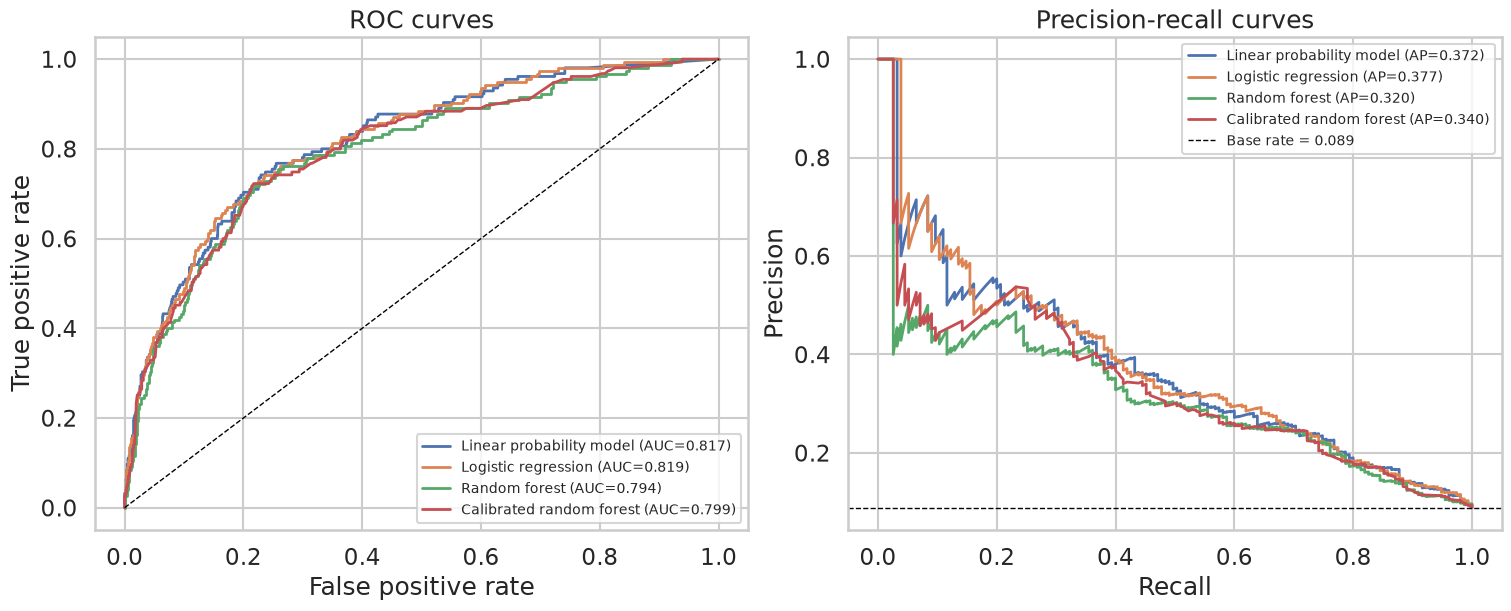

In [8]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

for model_name, prob in model_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    precision, recall, _ = precision_recall_curve(y_test, prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={roc_auc_score(y_test, prob):.3f})")
    axes[1].plot(recall, precision, linewidth=2, label=f"{model_name} (AP={average_precision_score(y_test, prob):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[0].set_title('ROC curves')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend(fontsize=10)

baseline_precision = y_test.mean()
axes[1].axhline(baseline_precision, linestyle='--', color='black', linewidth=1, label=f'Base rate = {baseline_precision:.3f}')
axes[1].set_title('Precision-recall curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=10)

plt.show()



The ROC view treats positives and negatives symmetrically, which is often useful for overall separation. But operations teams rarely feel symmetry. Missing a true breach and issuing an unnecessary alert do not usually hurt in the same way. When the positive class is relatively rare, the precision-recall curve often gives the more operationally honest picture because it asks: *when we escalate cases, how often are we right*?

That is the key lesson from the imbalanced-class literature: a model can look respectable in ROC space while still producing too many low-value alerts in practice (Davis & Goadrich, 2006; Saito & Rehmsmeier, 2015).



## 7. Calibration: Can We Trust the Numbers as Probabilities?

Suppose a model assigns 0.30 risk to a large collection of cases. If the model is well calibrated, then roughly 30% of those cases should actually breach. Calibration is therefore a statement about *long-run frequency alignment*.

This matters whenever probabilities feed downstream decisions:

- staffing plans based on expected counts of future failures;
- intervention policies triggered above a risk threshold;
- business cases that compare expected savings against expected escalation cost;
- communication with stakeholders who interpret the score literally.

We now examine calibration curves and reliability tables.


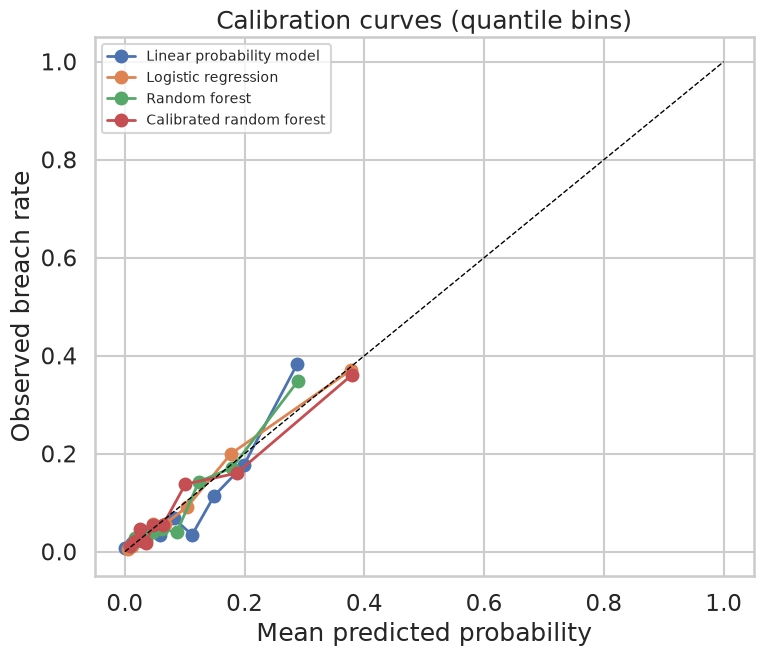

Logistic regression reliability table


,bin,count,mean_predicted,observed_rate,calibration_gap
0,"(-0.00019099999999999998, 0.00889]",175,0.005685,0.005714,0.000030
1,"(0.00889, 0.0141]",175,0.011402,0.011429,0.000027
2,"(0.0141, 0.0212]",175,0.017851,0.028571,0.010720
3,"(0.0212, 0.0297]",175,0.025147,0.034286,0.009138
4,"(0.0297, 0.0394]",175,0.034386,0.028571,-0.005814
5,"(0.0394, 0.055]",175,0.046656,0.057143,0.010487
6,"(0.055, 0.081]",175,0.067155,0.057143,-0.010012
7,"(0.081, 0.129]",175,0.104137,0.091429,-0.012709
8,"(0.129, 0.235]",175,0.177238,0.200000,0.022762
9,"(0.235, 0.858]",175,0.378439,0.371429,-0.007011


Calibrated random forest reliability table


,bin,count,mean_predicted,observed_rate,calibration_gap
0,"(-0.000999, 0.0132]",175,0.009,0.011,0.003
1,"(0.0132, 0.0227]",180,0.018,0.022,0.005
2,"(0.0227, 0.0263]",170,0.025,0.047,0.022
3,"(0.0263, 0.0315]",184,0.028,0.022,-0.006
4,"(0.0315, 0.0385]",167,0.035,0.018,-0.017
5,"(0.0385, 0.0564]",185,0.047,0.054,0.007
6,"(0.0564, 0.0737]",165,0.064,0.055,-0.009
7,"(0.0737, 0.139]",174,0.101,0.138,0.037
8,"(0.139, 0.223]",175,0.187,0.160,-0.027
9,"(0.223, 0.85]",175,0.378,0.360,-0.018


Using a 10-bin expected calibration error, **Logistic regression** is the most numerically reliable of the models shown, while **Linear probability model** is the least calibrated. For the random forest specifically, isotonic calibration improves the Brier score by **0.001** and the 10-bin ECE by **0.004**.

In [9]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, ax = plt.subplots(figsize=(8.5, 7))
for model_name, prob in model_predictions.items():
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', linewidth=2, label=model_name)

ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
ax.set_title('Calibration curves (quantile bins)')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed breach rate')
ax.legend(fontsize=10)
plt.show()

logit_reliability = reliability_table(y_test, model_predictions['Logistic regression'], bins=10)
rf_cal_reliability = reliability_table(y_test, model_predictions['Calibrated random forest'], bins=10)

print('Logistic regression reliability table')
smart_display(logit_reliability)
print('Calibrated random forest reliability table')
smart_display(rf_cal_reliability)

best_ece_model = metrics_table['ece_10_bins'].idxmin()
worst_ece_model = metrics_table['ece_10_bins'].idxmax()
rf_brier_delta = metrics_table.loc['Random forest', 'brier_score'] - metrics_table.loc['Calibrated random forest', 'brier_score']
rf_ece_delta = metrics_table.loc['Random forest', 'ece_10_bins'] - metrics_table.loc['Calibrated random forest', 'ece_10_bins']

if rf_brier_delta > 0 or rf_ece_delta > 0:
    rf_note = (
        f" For the random forest specifically, isotonic calibration improves the Brier score by **{rf_brier_delta:.3f}** "
        f"and the 10-bin ECE by **{rf_ece_delta:.3f}**."
    )
else:
    rf_note = (
        " In this particular run, isotonic calibration does not materially improve the random forest, which is itself a useful reminder that recalibration is an empirical fix, not a guarantee."
    )

display(
    Markdown(
        f"Using a 10-bin expected calibration error, **{best_ece_model}** is the most numerically reliable of the models shown, while **{worst_ece_model}** is the least calibrated." + rf_note
    )
)



A useful way to think about calibration is this: discrimination tells us *who should be near the top of the queue*; calibration tells us *how many of those high-risk cases we should expect to fail*. Decision systems need both.



## 8. Threshold Choice Is a Cost-Design Problem, Not a Software Default

Many packages convert probabilities to labels at a threshold of 0.50. That is convenient for software, but it is rarely the right threshold for a real workflow.

If missing an SLA breach is much more expensive than issuing an unnecessary escalation, then the threshold should generally be lower than 0.50. Conversely, if intervention capacity is extremely scarce, the threshold may need to be higher even if recall falls.

To make that trade-off concrete, suppose:

- a **false positive** (unnecessary escalation) costs about **$120** in extra analyst time and coordination;
- a **false negative** (missed breach) costs about **$1,500** in credits, churn risk, and operational cleanup.

These numbers are illustrative, but they are enough to show how threshold choice follows from the decision environment.


,threshold,alert_rate,precision,recall,false_positives,false_negatives,expected_cost_per_case,expected_cost_per_1000_cases,model
0,0.050,0.426,0.172,0.826,617,27,65.451,65451.429,Logistic regression
1,0.100,0.262,0.242,0.716,347,44,61.509,61508.571,Logistic regression
2,0.150,0.173,0.300,0.587,212,64,69.394,69394.286,Logistic regression
3,0.200,0.125,0.335,0.471,145,82,80.229,80228.571,Logistic regression
4,0.250,0.094,0.384,0.406,101,92,85.783,85782.857,Logistic regression
5,0.300,0.067,0.444,0.335,65,103,92.743,92742.857,Logistic regression
6,0.350,0.051,0.494,0.284,45,111,98.229,98228.571,Logistic regression
7,0.400,0.033,0.483,0.181,30,127,110.914,110914.286,Logistic regression
8,0.450,0.022,0.590,0.148,16,132,114.240,114240.000,Logistic regression
9,0.500,0.014,0.625,0.097,9,140,120.617,120617.143,Logistic regression


,threshold,alert_rate,precision,recall,false_positives,false_negatives,expected_cost_per_case,expected_cost_per_1000_cases,model
1,0.100,0.262,0.242,0.716,347,44,61.509,61508.571,Logistic regression
11,0.100,0.248,0.244,0.684,328,49,64.491,64491.429,Calibrated random forest


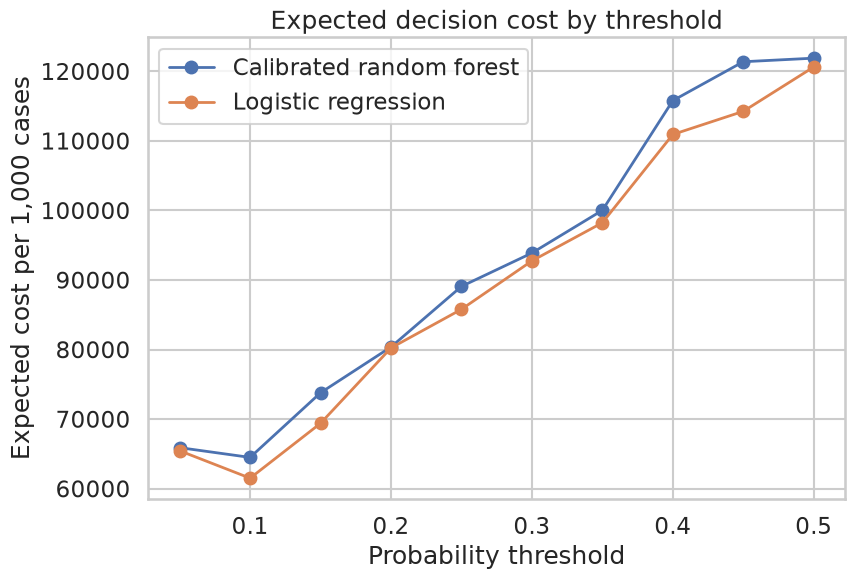

Under the assumed cost ratio, the lowest observed cost in this threshold sweep comes from **Logistic regression** at a threshold of **0.10**, with an expected cost of about **$61,509 per 1,000 cases** and an alert rate of **26.2%**. The deeper lesson is broader than the exact number: the best threshold is a business design choice tied to harm, capacity, and tolerance for missed events.

In [10]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
thresholds = np.arange(0.05, 0.55, 0.05)
logit_thresholds = threshold_table(y_test, model_predictions['Logistic regression'], thresholds, fp_cost=120, fn_cost=1500)
logit_thresholds['model'] = 'Logistic regression'
rf_cal_thresholds = threshold_table(y_test, model_predictions['Calibrated random forest'], thresholds, fp_cost=120, fn_cost=1500)
rf_cal_thresholds['model'] = 'Calibrated random forest'

threshold_results = pd.concat([logit_thresholds, rf_cal_thresholds], ignore_index=True)
smart_display(threshold_results)

best_thresholds = threshold_results.loc[
    threshold_results.groupby('model')['expected_cost_per_1000_cases'].idxmin()
].sort_values('expected_cost_per_1000_cases')
smart_display(best_thresholds)

fig, ax = plt.subplots(figsize=(9, 6))
for model_name, group in threshold_results.groupby('model'):
    ax.plot(group['threshold'], group['expected_cost_per_1000_cases'], marker='o', linewidth=2, label=model_name)

ax.set_title('Expected decision cost by threshold')
ax.set_xlabel('Probability threshold')
ax.set_ylabel('Expected cost per 1,000 cases')
ax.legend()
plt.show()

winner = best_thresholds.iloc[0]
display(
    Markdown(
        f"Under the assumed cost ratio, the lowest observed cost in this threshold sweep comes from **{winner['model']}** at a threshold of **{winner['threshold']:.2f}**, "
        f"with an expected cost of about **${winner['expected_cost_per_1000_cases']:,.0f} per 1,000 cases** and an alert rate of **{winner['alert_rate']:.1%}**. "
        "The deeper lesson is broader than the exact number: the best threshold is a business design choice tied to harm, capacity, and tolerance for missed events."
    )
)



## 9. What Should Change in Your Statistical Thinking

There are several ideas worth keeping:

1. **Binary classification is about probabilities, rankings, thresholds, and labels.** In decision systems, the probability scale is part of the product.
2. **Accuracy is a weak summary under class imbalance.** It must be read alongside recall, precision, and the base rate.
3. **The linear probability model is a useful teaching baseline.** Its simplicity is valuable, and bounded probabilities matter for a deployed risk engine.
4. **Ranking and calibration are different.** ROC AUC can be strong while probabilities remain numerically unreliable.
5. **Thresholds should be chosen, not inherited.** A model becomes actionable only when paired with explicit costs and operational capacity.

Those principles show up well beyond premium-support triage. The same logic appears in fraud detection, lending, medical screening, retention targeting, equipment failure monitoring, and policy evaluation pipelines that triage scarce interventions. Statistical maturity in classification means recognizing that the question is never only "which model predicts best?" It is also "what kind of error matters, what probability statements can be trusted, and how will those numbers be used?"


## 10. Real-Data Companion: Bank Marketing, Leakage, and Calibration

The synthetic classification task lets us control the base rate and the data-generating process. The UCI Bank Marketing data add a real campaign setting. Each row represents a client contact from a Portuguese bank's direct-marketing campaign, and the target is whether the client subscribed to a term deposit. The predictors include client attributes, campaign history, contact timing, and broader economic indicators.

The key decision context is pre-campaign targeting. A model should score clients before the next outreach decision is made. This is why the `duration` variable is dangerous: it records the length of the last phone contact, which is known only after the call. It can be highly predictive while being unavailable at the decision time. Including it would create leakage and make the model look better than it would be in deployment.

The companion excludes `duration` and evaluates the quality of predicted probabilities. The experiment is not just classification accuracy. It asks whether probabilities are calibrated enough to support threshold decisions, resource allocation, or expected-value calculations under an imbalanced campaign outcome.

For clarity, the unit is a client campaign contact. The outcome is term-deposit subscription, and the experiment evaluates probability models under the information available before outreach. The leakage check is part of the dataset explanation because decision timing determines which variables are legitimate.

Data source: [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing).

,metric,value
0,Base subscription rate,0.117
1,ROC AUC,0.771
2,Average precision,0.412
3,Brier score,0.085


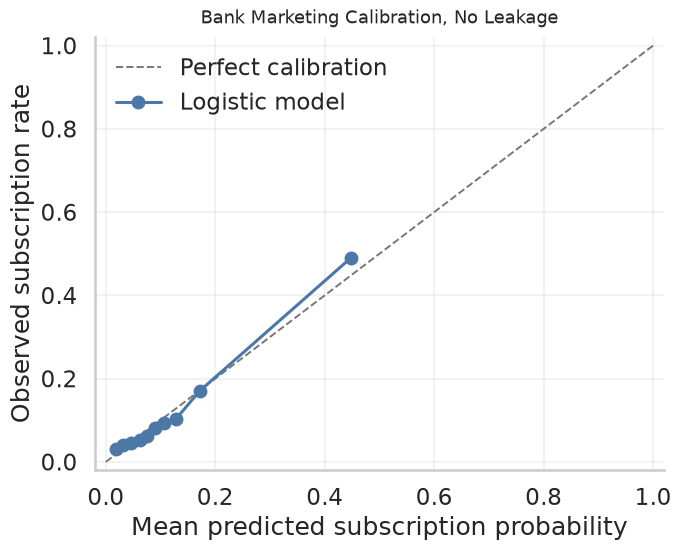

In [11]:
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_uci_bank_marketing, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.calibration import calibration_curve

    bank = load_uci_bank_marketing()
    y = (bank["y"] == "yes").astype(int)
    leakage_columns = ["duration", "y"]
    X = bank.drop(columns=leakage_columns)

    categorical = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    numeric = X.select_dtypes(include=[np.number]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=25), categorical),
            ("num", StandardScaler(), numeric),
        ]
    )
    model = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("logit", LogisticRegression(max_iter=2_000)),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=2026, stratify=y
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    metric_table = pd.DataFrame(
        [
            {"metric": "Base subscription rate", "value": y_test.mean()},
            {"metric": "ROC AUC", "value": roc_auc_score(y_test, proba)},
            {"metric": "Average precision", "value": average_precision_score(y_test, proba)},
            {"metric": "Brier score", "value": brier_score_loss(y_test, proba)},
        ]
    )
    smart_display(metric_table.round(4))

    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    fig, ax = plt.subplots(figsize=(6.7, 5.4), constrained_layout=True)
    ax.plot([0, 1], [0, 1], linestyle="--", color="#777777", linewidth=1.4, label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, marker="o", linewidth=2.2, color="#4C78A8", label="Logistic model")
    ax.set_title("Bank Marketing Calibration, No Leakage", fontsize=13, pad=10)
    ax.set_xlabel("Mean predicted subscription probability")
    ax.set_ylabel("Observed subscription rate")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, loc="upper left")
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "UCI Bank Marketing Dataset",
        "https://archive.ics.uci.edu/dataset/222/bank+marketing",
        "RUN_REAL_DATA_COMPANION",
    )

This companion is intentionally framed around decision timing. A model that uses post-call duration may look impressive, but it cannot guide pre-call targeting. Real classification work is full of traps like this: good metrics are not enough unless the features are available at the moment the decision is made.


## References

- Brier, G. W. (1950). *Verification of forecasts expressed in terms of probability*. *Monthly Weather Review, 78*(1), 1-3. [doi:10.1175/1520-0493(1950)078&lt;0001:VOFEIT&gt;2.0.CO;2](https://doi.org/10.1175/1520-0493%281950%29078%3C0001%3AVOFEIT%3E2.0.CO%3B2)
- Davis, J., & Goadrich, M. (2006). *The relationship between precision-recall and ROC curves*. In *Proceedings of the 23rd International Conference on Machine Learning* (pp. 233-240). [https://doi.org/10.1145/1143844.1143874](https://doi.org/10.1145/1143844.1143874)
- Gneiting, T., & Raftery, A. E. (2007). *Strictly proper scoring rules, prediction, and estimation*. *Journal of the American Statistical Association, 102*(477), 359-378. [https://doi.org/10.1198/016214506000001437](https://doi.org/10.1198/016214506000001437)
- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). *On calibration of modern neural networks*. *arXiv*. [https://doi.org/10.48550/arXiv.1706.04599](https://doi.org/10.48550/arXiv.1706.04599)
- Niculescu-Mizil, A., & Caruana, R. (2005). *Predicting good probabilities with supervised learning*. In *Proceedings of the 22nd International Conference on Machine Learning* (pp. 625-632). [https://doi.org/10.1145/1102351.1102430](https://doi.org/10.1145/1102351.1102430)
- Saito, T., & Rehmsmeier, M. (2015). *The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets*. *PLOS ONE, 10*(3), e0118432. [https://doi.org/10.1371/journal.pone.0118432](https://doi.org/10.1371/journal.pone.0118432)
